# Chapter 2: Hilbert's Axioms

**Source span.** Robin Hartshorne, *Geometry: Euclid and Beyond*, Chapter 2, printed pages 65-116, PDF pages 77-128, Sections 6-12.

**Chapter question.** What has to be named, assumed, or tested before Euclid-style geometric arguments become model-independent?

**Goal.** Treat Hilbert's axiom groups as inspectable model properties. By the end, a reader should be able to separate incidence, betweenness, segment congruence, angle congruence, Hilbert-plane structure, line-circle behavior, circle-circle behavior, and Euclidean-plane assumptions into explicit predicates and visual checks.

This notebook uses the source pages only for orientation. The prose, code, diagrams, checks, and lab data below are original teaching material.

## Translation Guide

| Source idea | Computational translation | What the notebook checks |
| --- | --- | --- |
| Points and lines are undefined terms | points are records; lines are subsets or equations | two points determine one line; two distinct lines share at most one point |
| Betweenness | a ternary relation A*B*C, often computed by collinearity plus an affine parameter | exactly one middle point on a three-point line; side-of-line signs explain separation |
| Segment congruence | a relation on endpoint pairs | copy a length onto a ray; add adjacent copied pieces |
| Angle congruence | a relation on pairs of rays from one vertex | copy an angle to a chosen side; SAS transfers the remaining data |
| Hilbert plane | a model satisfying incidence, betweenness, and congruence groups, but not the parallel axiom | neutral geometry: many Book I facts can be re-proved without parallel assumptions |
| Line-circle and circle-circle behavior | existence properties for intersections when one object has inside and outside witnesses | intersection counts and rational-plane obstructions expose why this must be axiomatized |
| Euclidean plane | a Hilbert plane plus circle-circle intersection and Playfair's parallel axiom | a property matrix distinguishes real, rational, finite, Hilbert, and Euclidean models |

**Route.** We first make incidence visible in a finite affine model. Then we add order through betweenness and Pasch-style separation. Next we add segment and angle transporters. With those groups in place, we compare Hilbert and Euclidean planes as model-property bundles, study intersection behavior, and finish with an applied model audit.

In [1]:
from __future__ import annotations

import json
import math
import sys
from itertools import combinations
from pathlib import Path


def find_book_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
            return candidate
        nested = candidate / "Euclid-and-Beyond"
        if (nested / "00-book-index.ipynb").exists() and (nested / "utils").exists():
            return nested
    raise RuntimeError("Could not find Euclid-and-Beyond book root")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

UNIT = "chapter-02"
CHAPTER_ROOT = BOOK_ROOT / "chapter-02-hilberts-axioms"
ARTIFACT_DIR = BOOK_ROOT / "artifacts" / UNIT
FIGURE_DIR = ARTIFACT_DIR / "figures"
INTERACTIVE_DIR = ARTIFACT_DIR / "interactive"
CHECK_DIR = ARTIFACT_DIR / "checks"
TABLE_DIR = ARTIFACT_DIR / "tables"
for directory in [FIGURE_DIR, INTERACTIVE_DIR, CHECK_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

from utils.artifacts import assert_artifact, display_artifact

print(f"BOOK_ROOT = {BOOK_ROOT.relative_to(BOOK_ROOT.parent)}")
print(f"Artifacts = {ARTIFACT_DIR.relative_to(BOOK_ROOT)}")

BOOK_ROOT = Euclid-and-Beyond
Artifacts = artifacts\chapter-02


In [2]:
import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import display

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "font.size": 10})
PALETTE = {
    "ink": "#172033", "blue": "#2563eb", "green": "#059669", "red": "#dc2626",
    "gold": "#ca8a04", "purple": "#7c3aed", "gray": "#64748b",
    "light_blue": "#dbeafe", "light_green": "#dcfce7", "light_gold": "#fef3c7", "light_red": "#fee2e2",
}
ARTIFACTS: dict[str, Path] = {}
CHECKS: dict[str, object] = {}


def rel(path: Path) -> str:
    return path.resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def save_figure(fig, filename: str, key: str, *, dpi: int = 170) -> Path:
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    assert_artifact(path, min_bytes=1024)
    ARTIFACTS[key] = path
    return path


def save_table(df: pd.DataFrame, filename: str, key: str) -> Path:
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    assert_artifact(path, min_bytes=64)
    ARTIFACTS[key] = path
    return path


def save_check(data: object, filename: str, key: str) -> Path:
    path = CHECK_DIR / filename
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")
    assert_artifact(path, min_bytes=64)
    ARTIFACTS[key] = path
    return path


def notebook_artifact_path(path: Path) -> Path:
    return Path("..") / Path(path).resolve().relative_to(BOOK_ROOT.resolve())


def show_artifact(path: Path, **kwargs):
    return display_artifact(notebook_artifact_path(path), **kwargs)


def cross2(u, v) -> float:
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    return float(u[0] * v[1] - u[1] * v[0])


def unit(v: np.ndarray) -> np.ndarray:
    norm = np.linalg.norm(v)
    if norm == 0:
        raise ValueError("zero vector")
    return v / norm


def orient(a, b, c) -> float:
    a, b, c = map(np.asarray, (a, b, c))
    return cross2(b - a, c - a)


def affine_between(a, b, c, *, tol=1e-9) -> bool:
    a, b, c = map(np.asarray, (a, b, c))
    if abs(orient(a, b, c)) > tol:
        return False
    return float(np.dot(b - a, b - c)) <= tol


def distance(a, b) -> float:
    return float(np.linalg.norm(np.asarray(a, dtype=float) - np.asarray(b, dtype=float)))


def angle_at(a, b, c) -> float:
    a, b, c = map(lambda p: np.asarray(p, dtype=float), (a, b, c))
    u = unit(a - b)
    v = unit(c - b)
    return float(math.acos(np.clip(np.dot(u, v), -1.0, 1.0)))


def line_circle_intersections_y(offset: float, radius: float = 1.0) -> list[tuple[float, float]]:
    gap = radius * radius - offset * offset
    if gap < -1e-12:
        return []
    if abs(gap) <= 1e-12:
        return [(0.0, offset)]
    root = math.sqrt(gap)
    return [(-root, offset), (root, offset)]


def circle_circle_intersections(c0, r0: float, c1, r1: float, *, tol=1e-9) -> list[tuple[float, float]]:
    c0 = np.asarray(c0, dtype=float)
    c1 = np.asarray(c1, dtype=float)
    d = np.linalg.norm(c1 - c0)
    if d < tol or d > r0 + r1 + tol or d < abs(r0 - r1) - tol:
        return []
    a = (r0*r0 - r1*r1 + d*d) / (2*d)
    h2 = r0*r0 - a*a
    p = c0 + a * (c1 - c0) / d
    if abs(h2) <= tol:
        return [tuple(p)]
    if h2 < 0:
        return []
    h = math.sqrt(h2)
    perp = np.array([-(c1 - c0)[1], (c1 - c0)[0]]) / d
    return [tuple(p + h*perp), tuple(p - h*perp)]

print("Chapter-specific helpers loaded.")

Chapter-specific helpers loaded.


## Visual Storyboard

The chapter is proof-heavy, so each visual has a model predicate or proof state attached.

| Item | Representation | Library route | Artifact |
| --- | --- | --- | --- |
| Incidence as uniqueness | finite affine incidence matrix plus a bad model | Matplotlib + finite combinatorics | incidence-model-uniqueness.png |
| Betweenness and separation | side-of-line signs, Pasch-style crossing | Matplotlib + orientation predicates | betweenness-pasch-separation.png |
| Segment and angle congruence | transporter diagrams and SAS residuals | Matplotlib + NumPy + SymPy | congruence-transport-and-sas.png |
| Hilbert versus Euclidean planes | model-property matrix | Pandas + Matplotlib | hilbert-plane-model-checks.png |
| Intersection behavior | line-circle and circle-circle phase cases | Matplotlib + Plotly | intersection-behavior-phase-diagram.png, circle-intersection-lab.html |
| Proof/model route | axiom dependency graph | NetworkX + Matplotlib | axiom-group-map.png |

The key distinction is that a drawing is not treated as evidence by itself. Each visual is paired with a count, residual, symbolic identity, or explicit model obstruction.

## Incidence: Lines as a Uniqueness Predicate

Hilbert starts with points and lines as undefined objects, then asks only for incidence behavior: two distinct points determine exactly one line, every line has at least two points, and not all points lie on one line. The first visual uses the affine plane over F_3 because it is small enough to audit completely. The right panel deliberately includes a bad incidence structure: two different line-subsets share the same two points. That failure is exactly what the uniqueness part of incidence forbids.

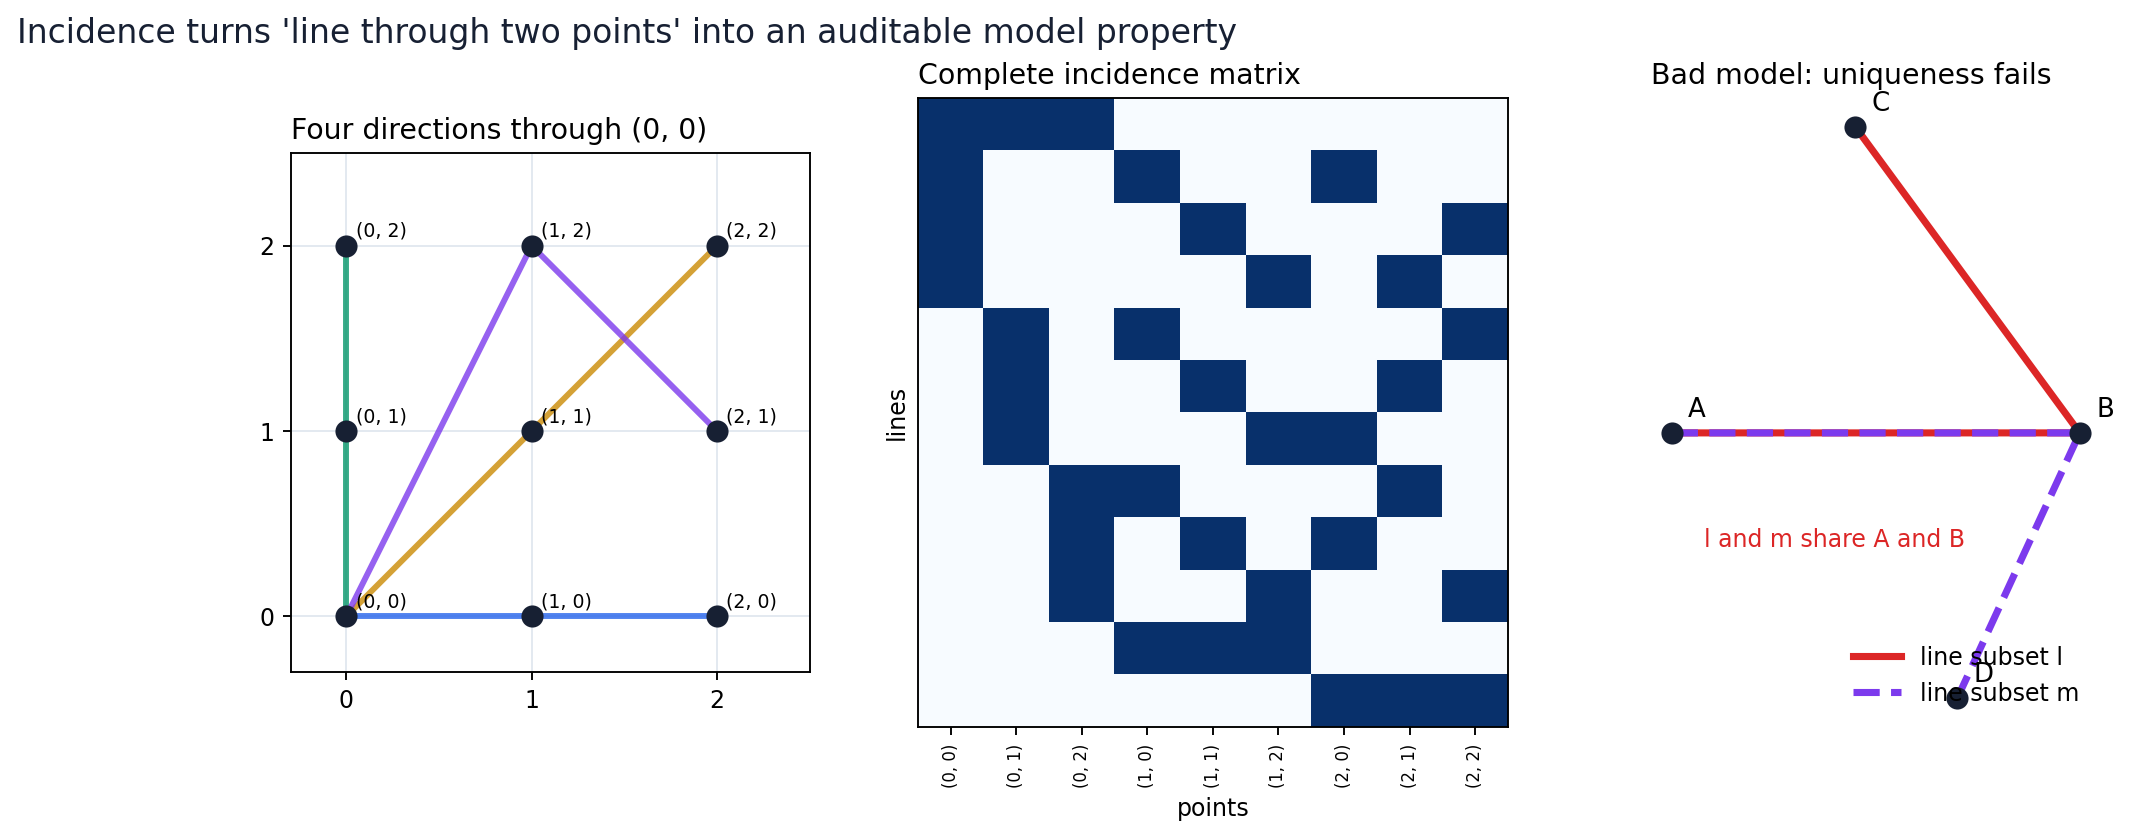

In [3]:
def finite_affine_plane(p: int = 3):
    points = [(x, y) for x in range(p) for y in range(p)]
    lines: set[frozenset[tuple[int, int]]] = set()
    for a in range(p):
        for b in range(p):
            if a == 0 and b == 0:
                continue
            for c in range(p):
                pts = frozenset((x, y) for x, y in points if (a*x + b*y - c) % p == 0)
                lines.add(pts)
    return points, sorted(lines, key=lambda L: sorted(L))

points_f3, lines_f3 = finite_affine_plane(3)
incidence = np.array([[1 if point in line else 0 for point in points_f3] for line in lines_f3])
pair_counts = [sum(p in line and q in line for line in lines_f3) for p, q in combinations(points_f3, 2)]
line_intersections = [len(a & b) for a, b in combinations(lines_f3, 2)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1.1, 1.25, 1.1]})
ax = axes[0]
ax.scatter([p[0] for p in points_f3], [p[1] for p in points_f3], s=70, color=PALETTE["ink"], zorder=3)
for point in points_f3:
    ax.text(point[0] + 0.05, point[1] + 0.05, str(point), fontsize=8)
representatives = [
    frozenset([(0,0),(1,0),(2,0)]), frozenset([(0,0),(0,1),(0,2)]),
    frozenset([(0,0),(1,1),(2,2)]), frozenset([(0,0),(1,2),(2,1)]),
]
for line, color in zip(representatives, [PALETTE["blue"], PALETTE["green"], PALETTE["gold"], PALETTE["purple"]]):
    xs, ys = zip(*sorted(line))
    ax.plot(xs, ys, color=color, linewidth=2.5, alpha=0.8)
ax.set_title("Four directions through (0, 0)", loc="left")
ax.set_xlim(-0.3, 2.5); ax.set_ylim(-0.3, 2.5); ax.set_aspect("equal")
ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2]); ax.grid(True, color="#e2e8f0")

ax = axes[1]
ax.imshow(incidence, cmap="Blues", aspect="auto")
ax.set_title("Complete incidence matrix", loc="left")
ax.set_xlabel("points"); ax.set_ylabel("lines")
ax.set_xticks(range(len(points_f3))); ax.set_xticklabels([str(p) for p in points_f3], rotation=90, fontsize=7)
ax.set_yticks([])

ax = axes[2]
bad_points = {"A": (0.0, 0.0), "B": (1.0, 0.0), "C": (0.45, 0.75), "D": (0.7, -0.65)}
for name, xy in bad_points.items():
    ax.scatter(*xy, s=70, color=PALETTE["ink"], zorder=3)
    ax.text(xy[0] + 0.04, xy[1] + 0.04, name, fontsize=11)
ax.plot([0, 1, 0.45], [0, 0, 0.75], color=PALETTE["red"], linewidth=3, label="line subset l")
ax.plot([0, 1, 0.7], [0, 0, -0.65], color=PALETTE["purple"], linewidth=3, linestyle="--", label="line subset m")
ax.text(0.08, -0.28, "l and m share A and B", color=PALETTE["red"], fontsize=10)
ax.set_title("Bad model: uniqueness fails", loc="left"); ax.set_aspect("equal"); ax.axis("off")
ax.legend(loc="lower right", frameon=False)
fig.suptitle("Incidence turns 'line through two points' into an auditable model property", x=0.01, ha="left", fontsize=14, color=PALETTE["ink"])
path = save_figure(fig, "incidence-model-uniqueness.png", "incidence")

CHECKS["incidence"] = {
    "finite_affine_order": 3,
    "point_count": len(points_f3),
    "line_count": len(lines_f3),
    "points_per_line": sorted(set(map(len, lines_f3))),
    "pair_line_count_values": sorted(set(pair_counts)),
    "distinct_line_intersection_sizes": sorted(set(line_intersections)),
    "bad_model_shared_points": 2,
}
assert len(points_f3) == 9
assert len(lines_f3) == 12
assert set(pair_counts) == {1}
assert set(line_intersections).issubset({0, 1})
show_artifact(path, width=1000)

## Betweenness: Order, Sides, and Pasch

Incidence only knows membership. Betweenness adds order along a line and lets us define segments, rays, interiors, and side-of-line separation. The useful computational move is to encode side by the sign of an oriented area. If two points have the same sign relative to a line, the segment between them does not cross the line; if the signs differ, it does.

Pasch's axiom is the warning light for hidden order assumptions. A line entering one side of a triangle, while avoiding the vertices, must leave through exactly one other side. The diagram below shows this as a sign-change computation, not as a copied Euclidean picture.

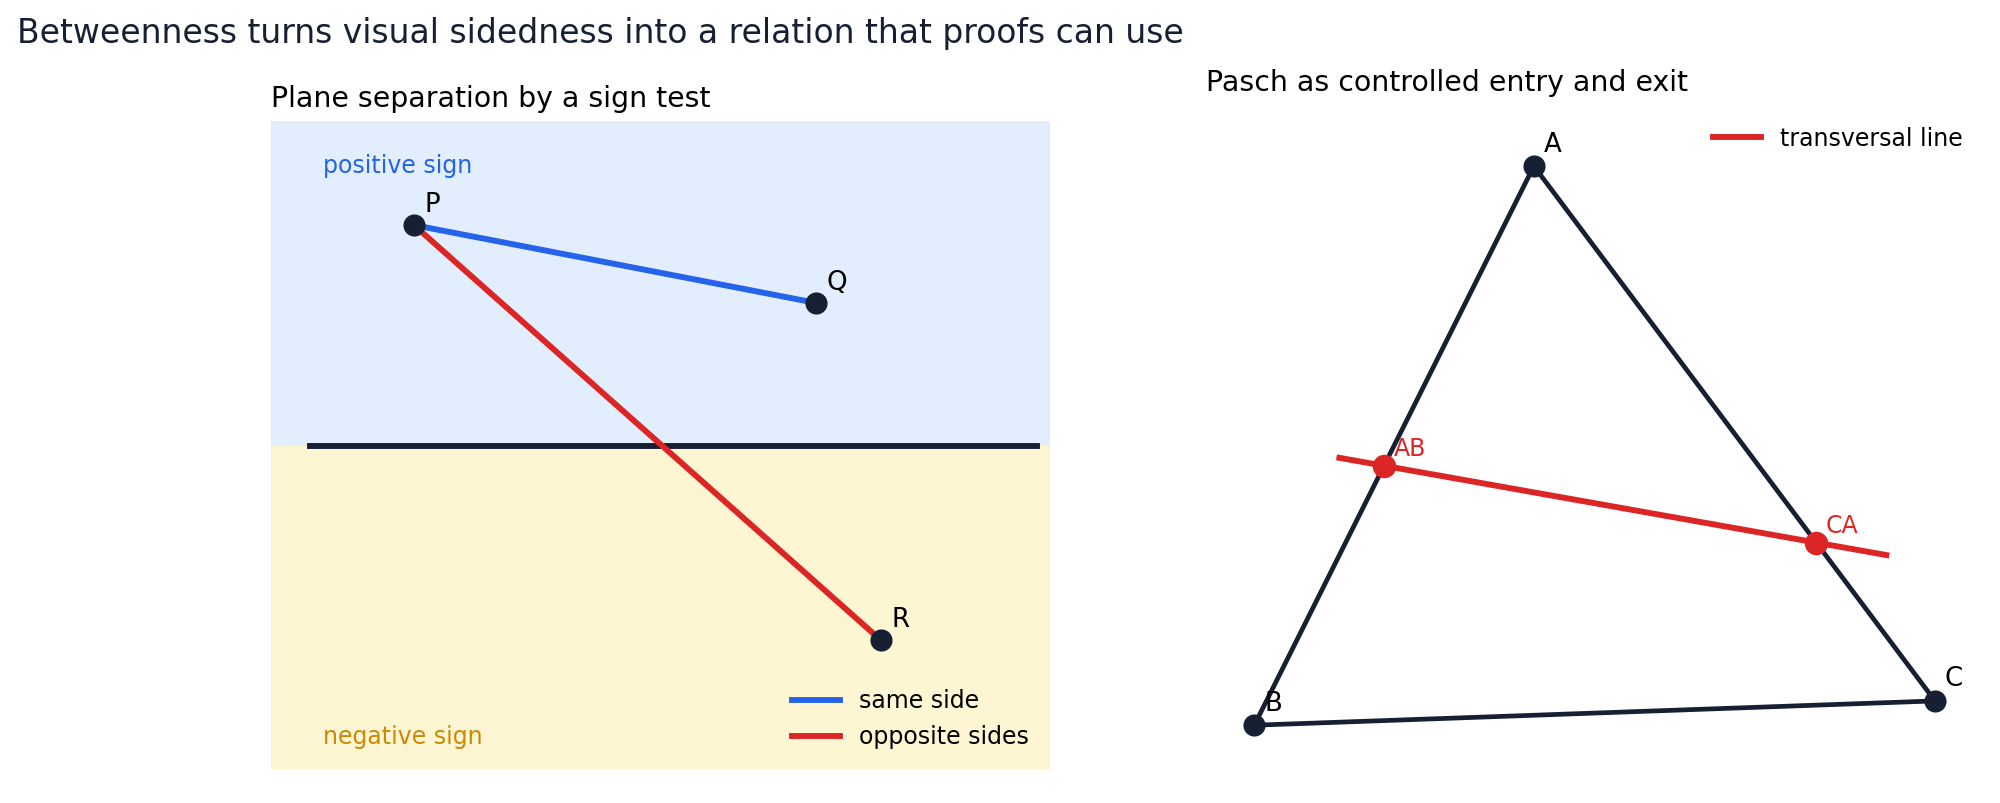

In [4]:
def segment_line_intersection(a, b, p, q, *, tol=1e-12):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    p = np.asarray(p, dtype=float); q = np.asarray(q, dtype=float)
    r = b - a; s = q - p
    denom = cross2(r, s)
    if abs(denom) < tol:
        return None
    t = cross2(p - a, s) / denom
    u = cross2(p - a, r) / denom
    if -tol <= t <= 1 + tol and -tol <= u <= 1 + tol:
        return a + t*r, float(t), float(u)
    return None

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
ax = axes[0]
line_p = np.array([-1.3, 0.0]); line_q = np.array([1.5, 0.0])
ax.axhspan(0, 1.4, color=PALETTE["light_blue"], alpha=0.8)
ax.axhspan(-1.4, 0, color=PALETTE["light_gold"], alpha=0.8)
ax.plot([line_p[0], line_q[0]], [0, 0], color=PALETTE["ink"], linewidth=2.5)
examples = {"P": np.array([-0.9, 0.85]), "Q": np.array([0.65, 0.55]), "R": np.array([0.9, -0.75])}
for name, xy in examples.items():
    ax.scatter(*xy, s=70, color=PALETTE["ink"], zorder=3); ax.text(xy[0]+0.04, xy[1]+0.05, name, fontsize=11)
ax.plot([examples["P"][0], examples["Q"][0]], [examples["P"][1], examples["Q"][1]], color=PALETTE["blue"], linewidth=2.5, label="same side")
ax.plot([examples["P"][0], examples["R"][0]], [examples["P"][1], examples["R"][1]], color=PALETTE["red"], linewidth=2.5, label="opposite sides")
ax.text(-1.25, 1.05, "positive sign", color=PALETTE["blue"]); ax.text(-1.25, -1.15, "negative sign", color=PALETTE["gold"])
ax.set_title("Plane separation by a sign test", loc="left"); ax.set_aspect("equal"); ax.set_xlim(-1.45,1.55); ax.set_ylim(-1.25,1.25); ax.axis("off"); ax.legend(frameon=False, loc="lower right")

ax = axes[1]
A = np.array([0.0, 1.55]); B = np.array([-1.15, -0.75]); C = np.array([1.65, -0.65])
L0 = np.array([-0.8, 0.35]); L1 = np.array([1.45, -0.05])
for U, V in [(A,B), (B,C), (C,A)]:
    ax.plot([U[0],V[0]], [U[1],V[1]], color=PALETTE["ink"], linewidth=2)
ax.plot([L0[0],L1[0]], [L0[1],L1[1]], color=PALETTE["red"], linewidth=2.5, label="transversal line")
side_hits = {}
for name, U, V in [("AB", A, B), ("BC", B, C), ("CA", C, A)]:
    hit = segment_line_intersection(U, V, L0, L1)
    if hit:
        point, t, u = hit
        if 1e-7 < t < 1 - 1e-7:
            side_hits[name] = point
            ax.scatter(*point, s=80, color=PALETTE["red"], zorder=4); ax.text(point[0]+0.04, point[1]+0.04, name, color=PALETTE["red"], fontsize=10)
for name, xy in [("A",A),("B",B),("C",C)]:
    ax.scatter(*xy, s=70, color=PALETTE["ink"], zorder=3); ax.text(xy[0]+0.04, xy[1]+0.06, name, fontsize=11)
ax.set_title("Pasch as controlled entry and exit", loc="left"); ax.set_aspect("equal"); ax.set_xlim(-1.35,1.85); ax.set_ylim(-1.0,1.8); ax.axis("off"); ax.legend(frameon=False, loc="upper right")
fig.suptitle("Betweenness turns visual sidedness into a relation that proofs can use", x=0.01, ha="left", fontsize=14, color=PALETTE["ink"])
path = save_figure(fig, "betweenness-pasch-separation.png", "betweenness")

side_values = {name: math.copysign(1, orient(line_p, line_q, xy)) for name, xy in examples.items()}
CHECKS["betweenness"] = {
    "side_signs": side_values,
    "same_side_segment_crosses_line": bool(segment_line_intersection(examples["P"], examples["Q"], line_p, line_q) is not None),
    "opposite_side_segment_crosses_line": bool(segment_line_intersection(examples["P"], examples["R"], line_p, line_q) is not None),
    "pasch_side_hits": sorted(side_hits),
    "affine_between_example": affine_between((0,0), (1,0), (3,0)),
}
assert side_values["P"] == side_values["Q"]
assert side_values["P"] != side_values["R"]
assert CHECKS["betweenness"]["same_side_segment_crosses_line"] is False
assert CHECKS["betweenness"]["opposite_side_segment_crosses_line"] is True
assert len(side_hits) == 2
show_artifact(path, width=1000)

## Congruence: Transporters Replace Informal Motion

The segment congruence axioms let us copy a length onto a ray and add adjacent copied pieces. The angle congruence axioms let us copy an angle to a chosen side of a line. SAS then becomes a model rule: if two sides and the included angle match, the remaining side and two angles are forced. The final panel uses a rigidly transformed triangle only as a diagnostic model: the residuals should vanish if the SAS rule is being respected.

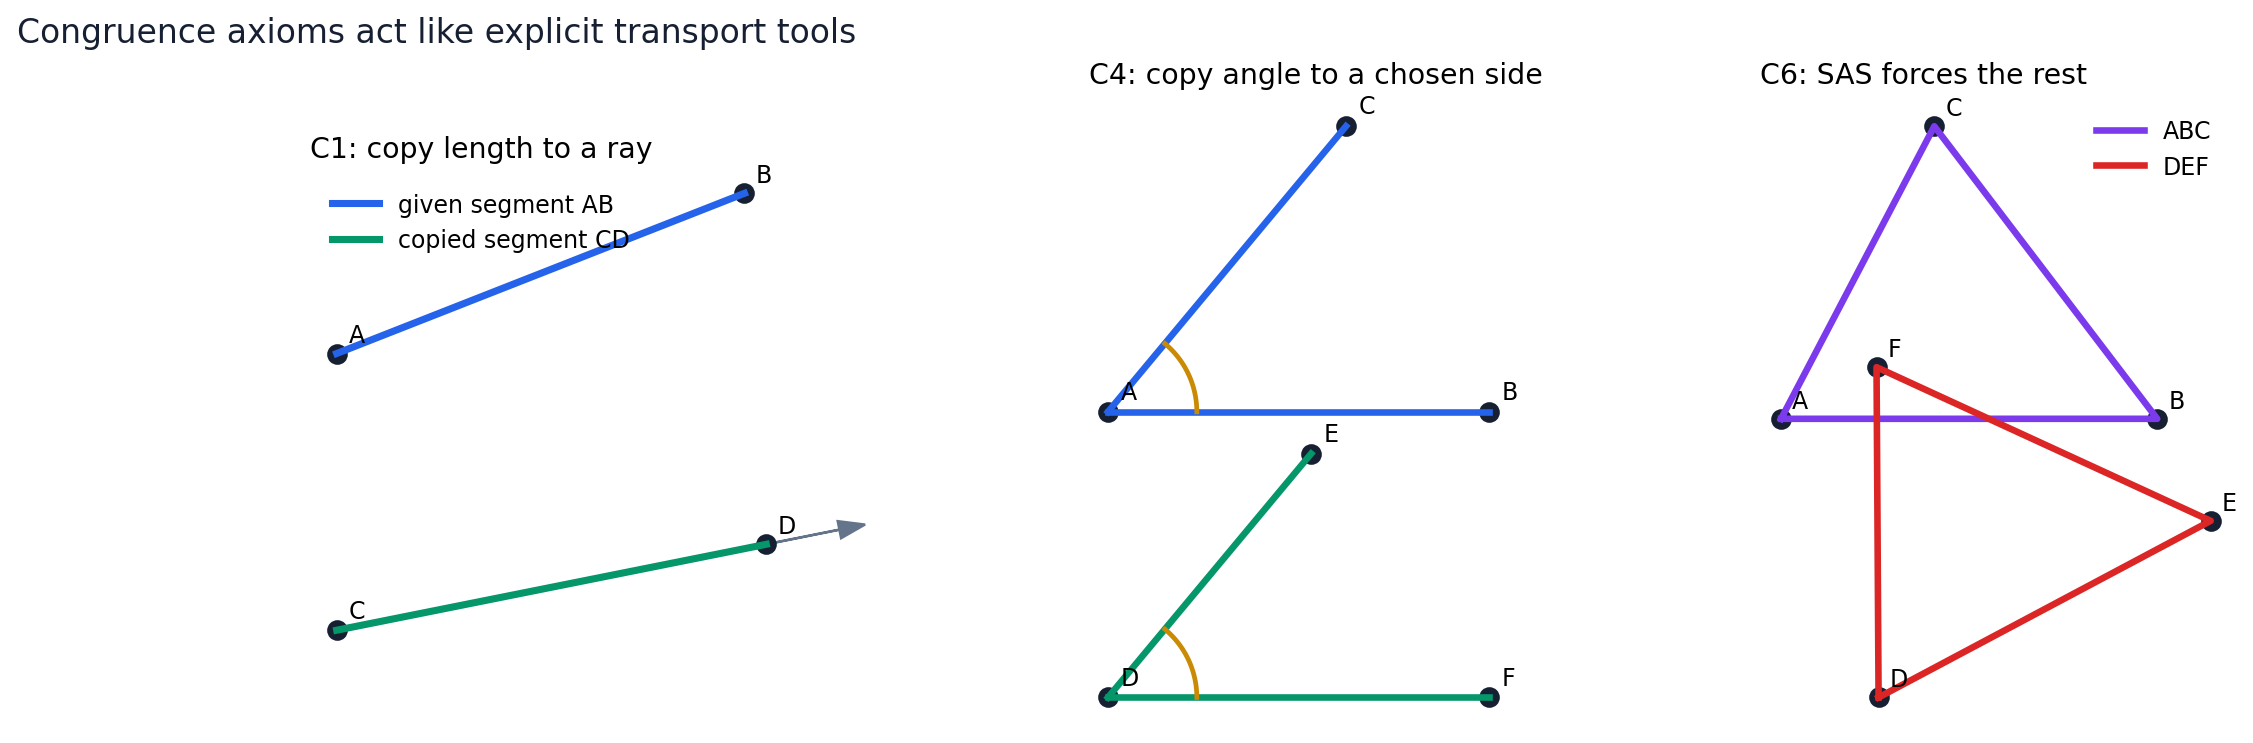

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
ax = axes[0]
A = np.array([0.0,0.0]); B = np.array([1.4,0.55]); C = np.array([0.0,-0.95]); ray_dir = unit(np.array([1.0,0.2])); D = C + distance(A,B)*ray_dir
ax.plot([A[0],B[0]], [A[1],B[1]], color=PALETTE["blue"], linewidth=3, label="given segment AB")
ax.arrow(C[0],C[1],1.85*ray_dir[0],1.85*ray_dir[1], head_width=0.06, length_includes_head=True, color=PALETTE["gray"])
ax.plot([C[0],D[0]], [C[1],D[1]], color=PALETTE["green"], linewidth=3, label="copied segment CD")
for name, xy in [("A",A),("B",B),("C",C),("D",D)]:
    ax.scatter(*xy, s=60, color=PALETTE["ink"]); ax.text(xy[0]+0.04, xy[1]+0.04, name)
ax.set_title("C1: copy length to a ray", loc="left"); ax.set_aspect("equal"); ax.axis("off"); ax.legend(frameon=False, loc="upper left")

ax = axes[1]
P = np.array([0.0,0.0]); Q = np.array([1.2,0.0]); R = np.array([0.75,0.9]); S = np.array([0.0,-0.9]); T = S + np.array([1.2,0.0])
theta = angle_at(Q, P, R); U = S + np.array([math.cos(theta), math.sin(theta)])
for start, end, color in [(P,Q,PALETTE["blue"]),(P,R,PALETTE["blue"]),(S,T,PALETTE["green"]),(S,U,PALETTE["green"] )]:
    ax.plot([start[0],end[0]], [start[1],end[1]], color=color, linewidth=2.8)
for name, xy in [("A",P),("B",Q),("C",R),("D",S),("F",T),("E",U)]:
    ax.scatter(*xy, s=60, color=PALETTE["ink"]); ax.text(xy[0]+0.04, xy[1]+0.04, name)
arc = np.linspace(0, theta, 40)
ax.plot(0.28*np.cos(arc), 0.28*np.sin(arc), color=PALETTE["gold"], linewidth=2)
ax.plot(S[0]+0.28*np.cos(arc), S[1]+0.28*np.sin(arc), color=PALETTE["gold"], linewidth=2)
ax.set_title("C4: copy angle to a chosen side", loc="left"); ax.set_aspect("equal"); ax.axis("off")

ax = axes[2]
tri1 = np.array([[0.0,0.0], [1.35,0.0], [0.55,1.05]])
phi = math.radians(28); Rmat = np.array([[math.cos(phi), -math.sin(phi)], [math.sin(phi), math.cos(phi)]])
tri2 = tri1 @ Rmat.T + np.array([0.35, -1.0])
for tri, color, label in [(tri1, PALETTE["purple"], "ABC"), (tri2, PALETTE["red"], "DEF")]:
    closed = np.vstack([tri, tri[0]]); ax.plot(closed[:,0], closed[:,1], color=color, linewidth=2.8, label=label)
for label, xy in zip(["A","B","C","D","E","F"], np.vstack([tri1, tri2])):
    ax.scatter(*xy, s=60, color=PALETTE["ink"]); ax.text(xy[0]+0.04, xy[1]+0.04, label)
ax.set_title("C6: SAS forces the rest", loc="left"); ax.set_aspect("equal"); ax.axis("off"); ax.legend(frameon=False, loc="upper right")
fig.suptitle("Congruence axioms act like explicit transport tools", x=0.01, ha="left", fontsize=14, color=PALETTE["ink"])
path = save_figure(fig, "congruence-transport-and-sas.png", "congruence")

segment_copy_residual = abs(distance(A,B) - distance(C,D))
angle_copy_residual = abs(angle_at(Q,P,R) - angle_at(T,S,U))
sas_residuals = {
    "included_side_one": abs(distance(tri1[0],tri1[1]) - distance(tri2[0],tri2[1])),
    "included_side_two": abs(distance(tri1[0],tri1[2]) - distance(tri2[0],tri2[2])),
    "included_angle": abs(angle_at(tri1[1],tri1[0],tri1[2]) - angle_at(tri2[1],tri2[0],tri2[2])),
    "forced_side": abs(distance(tri1[1],tri1[2]) - distance(tri2[1],tri2[2])),
    "forced_angle_B": abs(angle_at(tri1[0],tri1[1],tri1[2]) - angle_at(tri2[0],tri2[1],tri2[2])),
    "forced_angle_C": abs(angle_at(tri1[0],tri1[2],tri1[1]) - angle_at(tri2[0],tri2[2],tri2[1])),
}
x, y = sp.symbols("x y", positive=True)
segment_addition_identity = sp.simplify((x + y) - x - y)
CHECKS["congruence"] = {"segment_copy_residual": segment_copy_residual, "angle_copy_residual": angle_copy_residual, "sas_residuals": sas_residuals, "sympy_segment_addition_identity": str(segment_addition_identity)}
assert segment_copy_residual < 1e-12
assert angle_copy_residual < 1e-12
assert max(sas_residuals.values()) < 1e-12
assert segment_addition_identity == 0
show_artifact(path, width=1000)

## Hilbert and Euclidean Planes as Model-Property Bundles

A Hilbert plane is not just the familiar real coordinate plane. It is any model satisfying the incidence, betweenness, and congruence groups. A Euclidean plane adds the circle-circle intersection property and Playfair's parallel axiom. This distinction matters because some tempting models pass one group and fail another.

The dashboard below is not a classification theorem. It is a compact audit table that shows how different properties can come apart. In particular, the rational coordinate plane makes several hidden existence claims fail: a diagonal segment of length sqrt(2) cannot be copied to a rational point on the rational x-axis, and two rationally described circles can have only irrational intersection points.

,model,incidence,betweenness,segment_congruence,angle_congruence_SAS,circle_circle_E,parallel_P,diagnostic
0,real Cartesian plane R2,pass,pass,pass,pass,pass,pass,standard sampled model
1,rational coordinate plane Q2,pass,pass,fail,fragile,fail,pass,sqrt(2) and sqrt(3)/2 leave Q
2,finite affine plane F3,pass,fail,fail,fail,not Hilbert,pass,finite incidence is not ordered Hilbert geometry
3,abstract Hilbert plane,axiom,axiom,axiom,axiom,extra,extra,neutral geometry bundle
4,Euclidean plane,axiom,axiom,axiom,axiom,axiom,axiom,Hilbert plane plus E and P


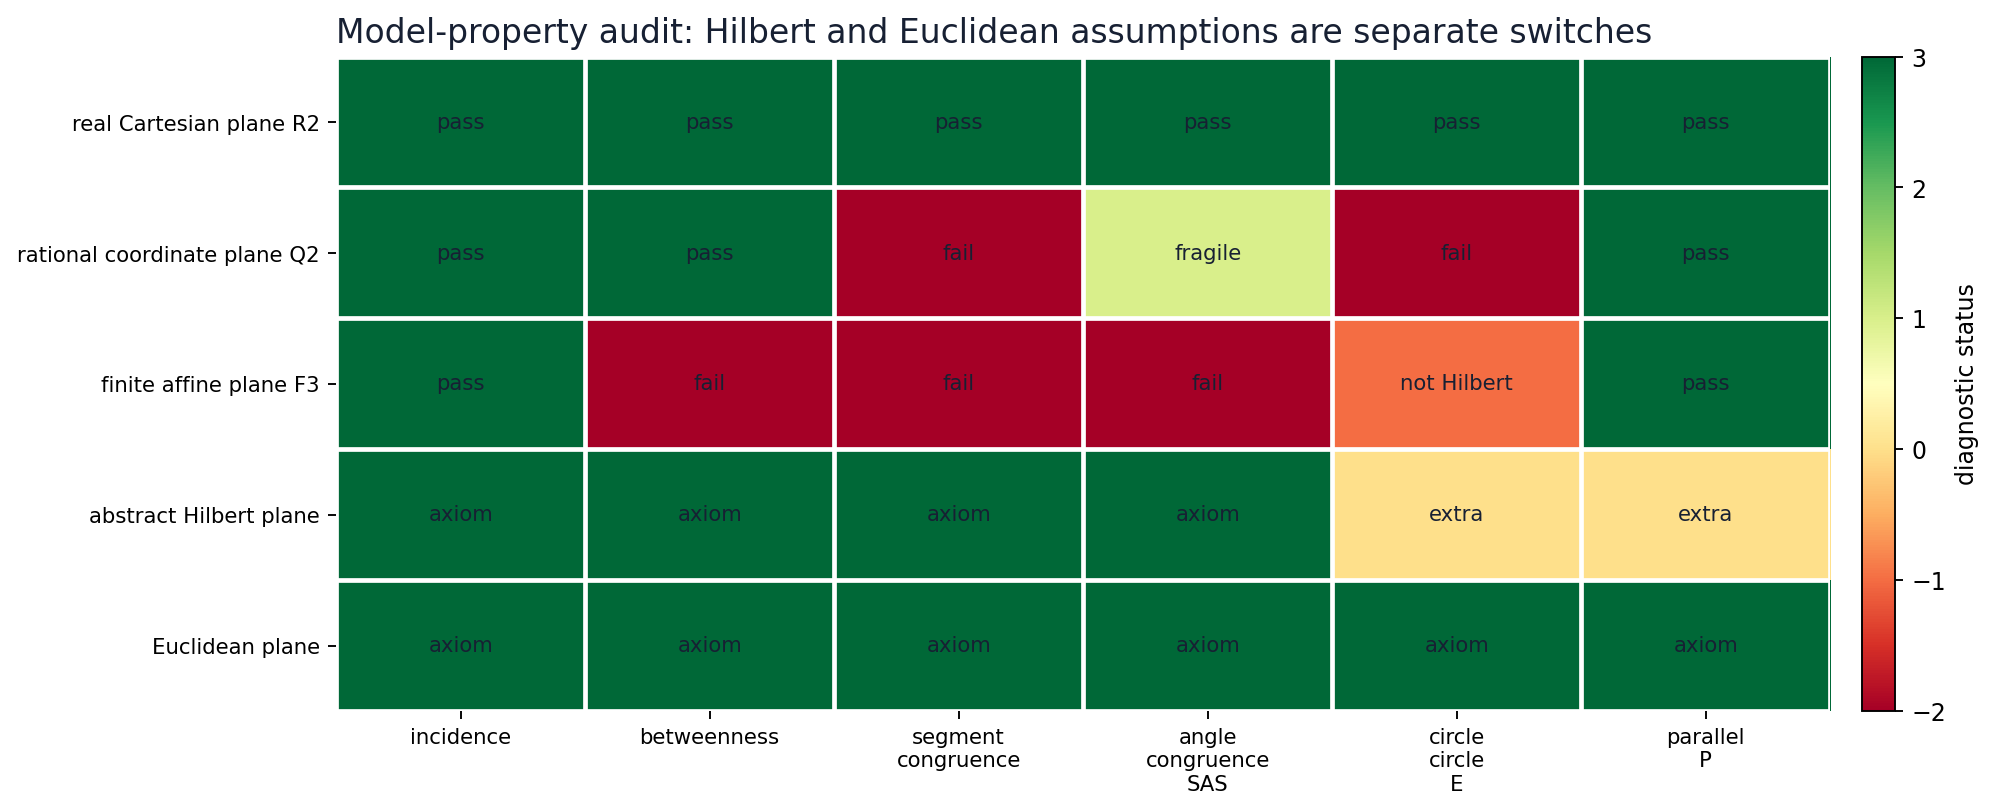

In [6]:
sqrt2_is_rational = bool(sp.sqrt(2).is_rational)
sqrt3_over_2_is_rational = bool((sp.sqrt(3) / 2).is_rational)
model_rows = [
    {"model": "real Cartesian plane R2", "incidence": "pass", "betweenness": "pass", "segment_congruence": "pass", "angle_congruence_SAS": "pass", "circle_circle_E": "pass", "parallel_P": "pass", "diagnostic": "standard sampled model"},
    {"model": "rational coordinate plane Q2", "incidence": "pass", "betweenness": "pass", "segment_congruence": "fail", "angle_congruence_SAS": "fragile", "circle_circle_E": "fail", "parallel_P": "pass", "diagnostic": "sqrt(2) and sqrt(3)/2 leave Q"},
    {"model": "finite affine plane F3", "incidence": "pass", "betweenness": "fail", "segment_congruence": "fail", "angle_congruence_SAS": "fail", "circle_circle_E": "not Hilbert", "parallel_P": "pass", "diagnostic": "finite incidence is not ordered Hilbert geometry"},
    {"model": "abstract Hilbert plane", "incidence": "axiom", "betweenness": "axiom", "segment_congruence": "axiom", "angle_congruence_SAS": "axiom", "circle_circle_E": "extra", "parallel_P": "extra", "diagnostic": "neutral geometry bundle"},
    {"model": "Euclidean plane", "incidence": "axiom", "betweenness": "axiom", "segment_congruence": "axiom", "angle_congruence_SAS": "axiom", "circle_circle_E": "axiom", "parallel_P": "axiom", "diagnostic": "Hilbert plane plus E and P"},
]
model_df = pd.DataFrame(model_rows)
table_path = save_table(model_df, "model-property-audit.csv", "model_property_audit")
status_score = {"pass": 3, "axiom": 3, "fragile": 1, "extra": 0, "not Hilbert": -1, "fail": -2}
cols = ["incidence", "betweenness", "segment_congruence", "angle_congruence_SAS", "circle_circle_E", "parallel_P"]
score = np.array([[status_score[row[col]] for col in cols] for row in model_rows])
fig, ax = plt.subplots(figsize=(12, 5.0))
image = ax.imshow(score, cmap=plt.cm.RdYlGn, vmin=-2, vmax=3, aspect="auto")
for i, row in enumerate(model_rows):
    for j, col in enumerate(cols):
        ax.text(j, i, row[col], ha="center", va="center", fontsize=9, color=PALETTE["ink"])
ax.set_xticks(range(len(cols))); ax.set_xticklabels([c.replace("_", "\n") for c in cols], fontsize=9)
ax.set_yticks(range(len(model_rows))); ax.set_yticklabels([row["model"] for row in model_rows], fontsize=9)
ax.set_title("Model-property audit: Hilbert and Euclidean assumptions are separate switches", loc="left", color=PALETTE["ink"], fontsize=14)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-0.5, len(cols), 1), minor=True); ax.set_yticks(np.arange(-0.5, len(model_rows), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2); ax.tick_params(which="minor", bottom=False, left=False)
fig.colorbar(image, ax=ax, fraction=0.035, pad=0.02, label="diagnostic status")
path = save_figure(fig, "hilbert-plane-model-checks.png", "model_checks")
CHECKS["model_property_audit"] = {"rational_sqrt2_is_rational": sqrt2_is_rational, "rational_sqrt3_over_2_is_rational": sqrt3_over_2_is_rational, "finite_affine_pair_uniqueness": set(pair_counts) == {1}, "models": model_df.to_dict(orient="records")}
assert sqrt2_is_rational is False
assert sqrt3_over_2_is_rational is False
assert model_df.loc[model_df["model"] == "rational coordinate plane Q2", "circle_circle_E"].iloc[0] == "fail"
display(model_df)
show_artifact(path, width=1000)

## Line-Circle and Circle-Circle Intersection Behavior

The source chapter introduces an additional intersection axiom because Hilbert-plane axioms alone do not guarantee every ruler-and-compass existence step. In coordinates over the real numbers, the behavior is familiar: a line at distance less than the radius is a secant, equal distance is a tangent, and greater distance misses. Two circles behave similarly by comparing the center distance with the sum and difference of radii.

The visual and the interactive lab make the existence clause concrete. The important inspection target is not the circle artwork; it is the transition from zero to one to two intersections and the inside/outside witness that forces an intersection in a Euclidean plane.

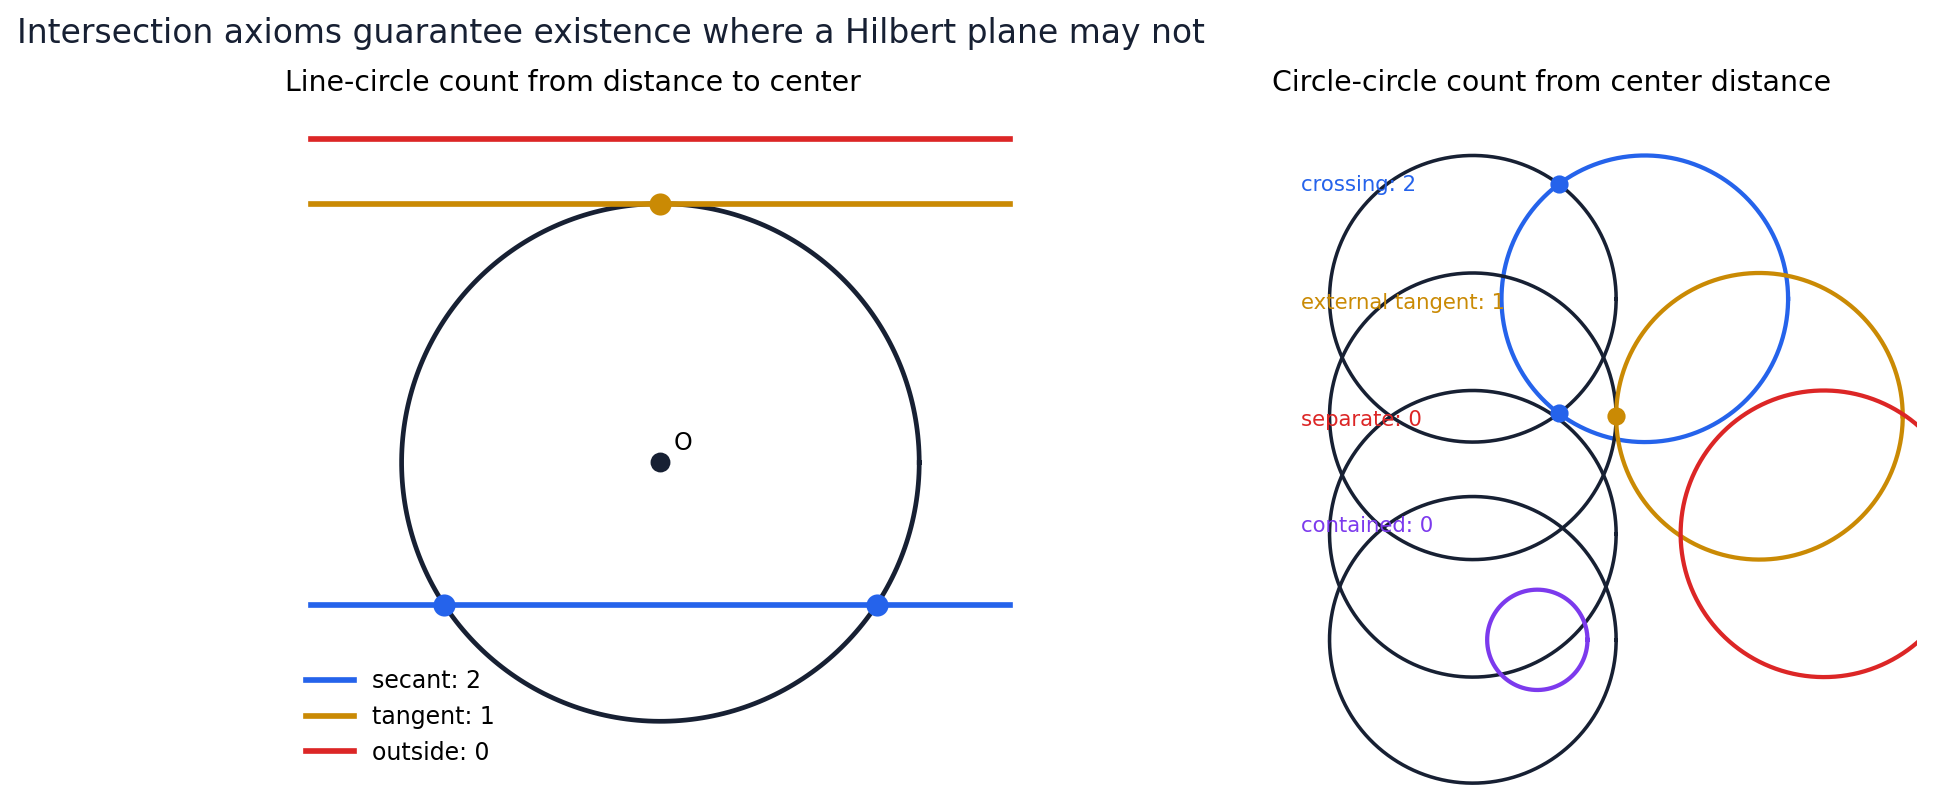

,center_distance,unit_circle_intersections
0,0.25,2
1,0.50,2
2,0.75,2
3,1.00,2
4,1.25,2
5,1.50,2
6,1.75,2
7,2.00,1
8,2.25,0
9,2.50,0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
ax = axes[0]
angles = np.linspace(0, 2*math.pi, 300)
ax.plot(np.cos(angles), np.sin(angles), color=PALETTE["ink"], linewidth=2)
line_offsets = [-0.55, 1.0, 1.25]
line_labels = ["secant: 2", "tangent: 1", "outside: 0"]
line_colors = [PALETTE["blue"], PALETTE["gold"], PALETTE["red"]]
line_counts = {}
for y0, label, color in zip(line_offsets, line_labels, line_colors):
    hits = line_circle_intersections_y(y0)
    line_counts[label] = len(hits)
    ax.plot([-1.35, 1.35], [y0, y0], color=color, linewidth=2.4, label=label)
    for hit in hits:
        ax.scatter(*hit, s=70, color=color, zorder=4)
ax.scatter(0,0, s=55, color=PALETTE["ink"]); ax.text(0.05,0.05,"O")
ax.set_title("Line-circle count from distance to center", loc="left"); ax.set_aspect("equal"); ax.set_xlim(-1.45,1.45); ax.set_ylim(-1.25,1.38); ax.axis("off"); ax.legend(frameon=False, loc="lower left")

ax = axes[1]
cases = [
    ((0,0),1,(1.2,0),1,"crossing: 2",PALETTE["blue"]),
    ((0,0),1,(2.0,0),1,"external tangent: 1",PALETTE["gold"]),
    ((0,0),1,(2.45,0),1,"separate: 0",PALETTE["red"]),
    ((0,0),1,(0.45,0),0.35,"contained: 0",PALETTE["purple"]),
]
circle_counts = {}; y_offsets = [1.2, 0.38, -0.44, -1.18]
for (c0, r0, c1, r1, label, color), yshift in zip(cases, y_offsets):
    c0 = np.array(c0, dtype=float) + np.array([0.0, yshift]); c1 = np.array(c1, dtype=float) + np.array([0.0, yshift])
    ax.plot(c0[0] + r0*np.cos(angles), c0[1] + r0*np.sin(angles), color=PALETTE["ink"], linewidth=1.5)
    ax.plot(c1[0] + r1*np.cos(angles), c1[1] + r1*np.sin(angles), color=color, linewidth=1.8)
    hits = circle_circle_intersections(c0, r0, c1, r1); circle_counts[label] = len(hits)
    for hit in hits:
        ax.scatter(*hit, s=45, color=color, zorder=4)
    ax.text(-1.2, yshift + 0.75, label, color=color, fontsize=9)
ax.set_title("Circle-circle count from center distance", loc="left"); ax.set_aspect("equal"); ax.set_xlim(-1.4,3.1); ax.set_ylim(-2.2,2.55); ax.axis("off")
fig.suptitle("Intersection axioms guarantee existence where a Hilbert plane may not", x=0.01, ha="left", fontsize=14, color=PALETTE["ink"])
phase_path = save_figure(fig, "intersection-behavior-phase-diagram.png", "intersection_phase")

frames = []
distances = [0.55, 1.0, 1.45, 2.0, 2.45]
base_angles = np.linspace(0, 2*math.pi, 240)
for d in distances:
    c0 = np.array([0.0,0.0]); c1 = np.array([d,0.0]); hits = circle_circle_intersections(c0,1.0,c1,1.0)
    traces = [
        go.Scatter(x=np.cos(base_angles), y=np.sin(base_angles), mode="lines", name="Gamma", line=dict(color="#172033", width=3)),
        go.Scatter(x=d + np.cos(base_angles), y=np.sin(base_angles), mode="lines", name="Delta", line=dict(color="#2563eb", width=3)),
        go.Scatter(x=[p[0] for p in hits], y=[p[1] for p in hits], mode="markers", name="intersections", marker=dict(size=10, color="#dc2626")),
    ]
    frames.append(go.Frame(data=traces, name=f"d={d:.2f}"))
fig_plotly = go.Figure(data=frames[0].data, frames=frames)
fig_plotly.update_layout(title="Circle-circle intersection lab: move the center distance", width=760, height=540, xaxis=dict(range=[-1.35,3.65], scaleanchor="y", zeroline=False), yaxis=dict(range=[-1.55,1.55], zeroline=False), showlegend=True, sliders=[{"steps": [{"method":"animate", "label": f"d={d:.2f}", "args": [[f"d={d:.2f}"], {"mode":"immediate", "frame":{"duration":0, "redraw":True}, "transition":{"duration":0}}]} for d in distances], "active":0}])
interactive_path = INTERACTIVE_DIR / "circle-intersection-lab.html"
fig_plotly.write_html(interactive_path, include_plotlyjs=True, full_html=True)
assert_artifact(interactive_path, min_bytes=10000); ARTIFACTS["circle_intersection_lab"] = interactive_path
sweep_rows = []
for d in np.linspace(0.25, 2.75, 11):
    hits = circle_circle_intersections((0,0),1.0,(float(d),0),1.0)
    sweep_rows.append({"center_distance": round(float(d), 3), "unit_circle_intersections": len(hits)})
sweep_df = pd.DataFrame(sweep_rows)
sweep_path = save_table(sweep_df, "circle-intersection-sweep.csv", "intersection_sweep")
CHECKS["intersections"] = {"line_circle_counts": line_counts, "circle_circle_counts": circle_counts, "slider_distances": distances, "sweep": sweep_rows, "rational_line_circle_obstruction": "x^2=2 has no rational solution on y=0", "rational_circle_circle_obstruction": "unit circles centered at (0,0) and (1,0) meet at y=+-sqrt(3)/2"}
assert line_counts["secant: 2"] == 2
assert line_counts["tangent: 1"] == 1
assert line_counts["outside: 0"] == 0
assert circle_counts["crossing: 2"] == 2
assert circle_counts["external tangent: 1"] == 1
assert sweep_df["unit_circle_intersections"].max() == 2
show_artifact(phase_path, width=1000)
show_artifact(interactive_path, width="100%", height=560)
display(sweep_df)

## Proof Route: Which Axioms Feed Which Results?

The chapter repeatedly reinterprets Euclid's moves as consequences of named permissions. The graph is a proof-state map. Incidence feeds uniqueness of lines. Betweenness feeds separation, Pasch, interiors, rays, and crossbar-style arguments. Congruence feeds segment arithmetic, angle comparison, and SAS. Adding the circle-circle intersection axiom validates the construction steps that require actual intersection points. Adding the parallel axiom turns neutral Hilbert geometry into the Euclidean plane used for parallel and area results.

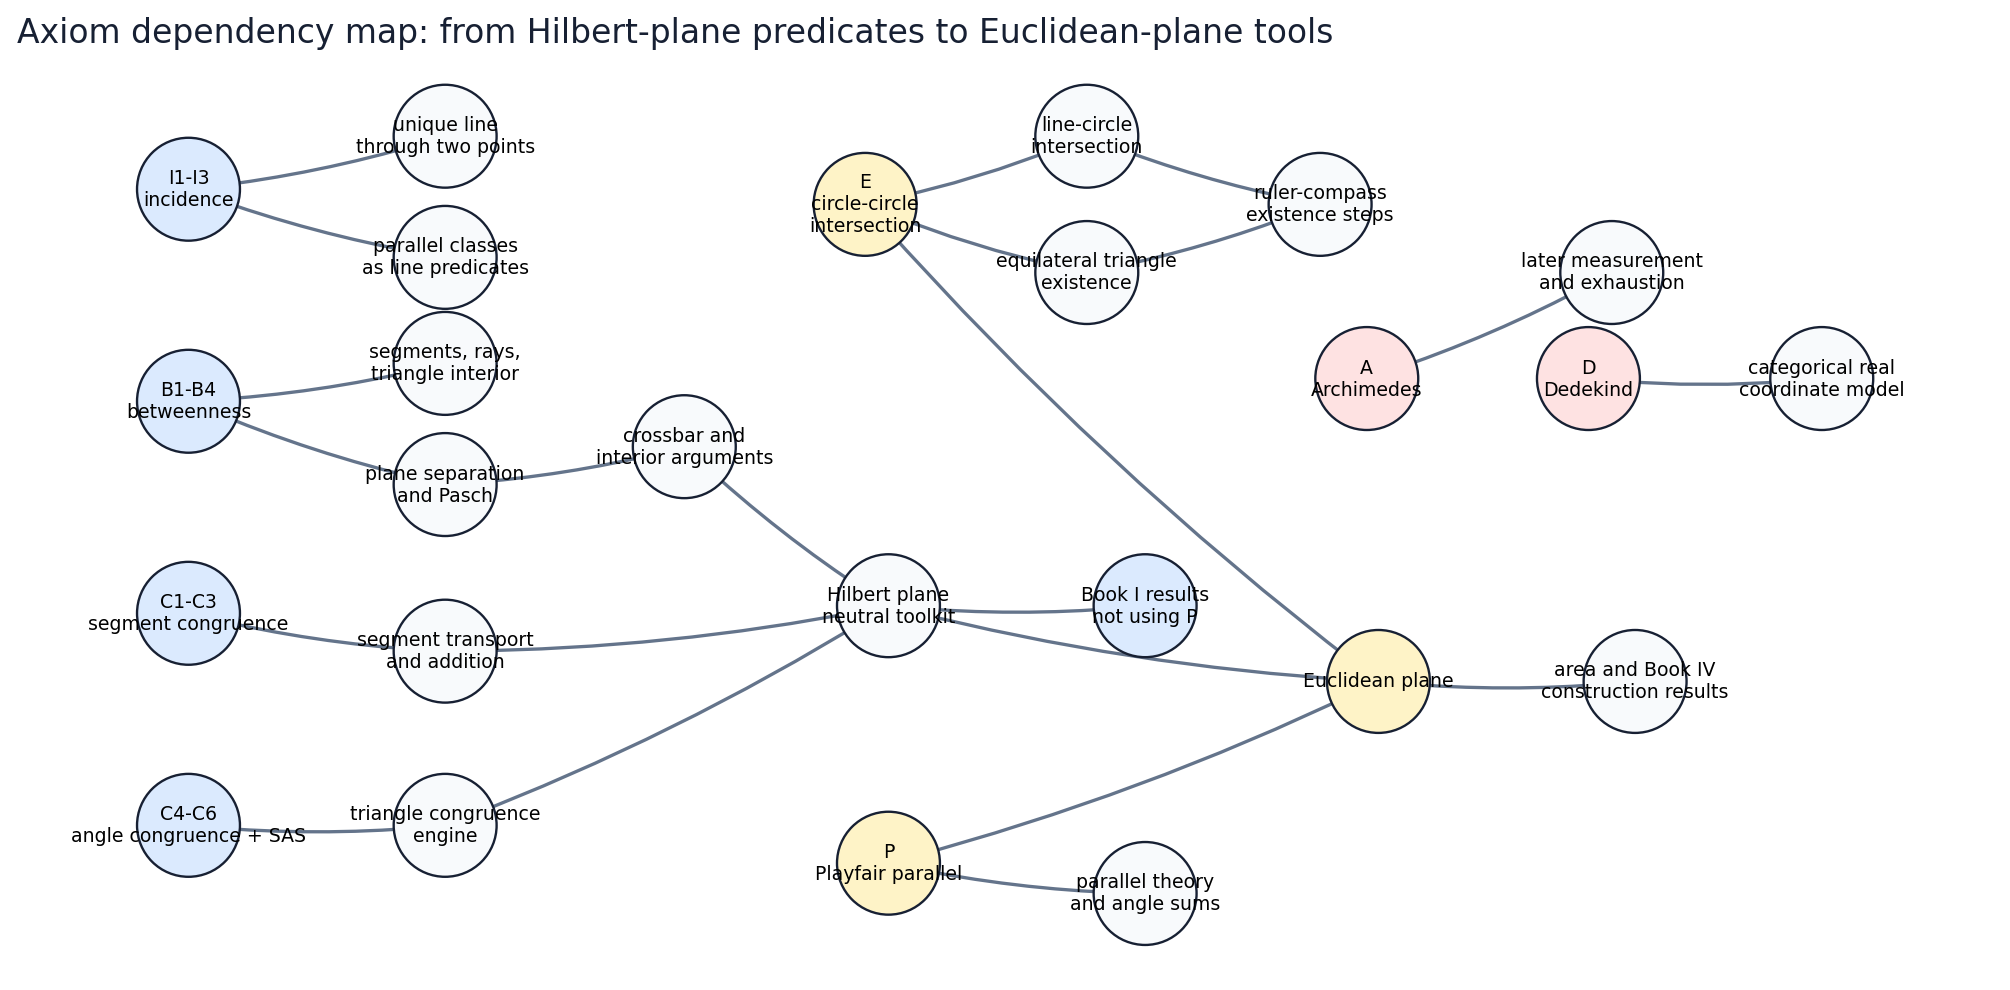

In [8]:
graph = nx.DiGraph()
edges = [
    ("I1-I3\nincidence", "unique line\nthrough two points"), ("I1-I3\nincidence", "parallel classes\nas line predicates"),
    ("B1-B4\nbetweenness", "segments, rays,\ntriangle interior"), ("B1-B4\nbetweenness", "plane separation\nand Pasch"),
    ("plane separation\nand Pasch", "crossbar and\ninterior arguments"),
    ("C1-C3\nsegment congruence", "segment transport\nand addition"), ("C4-C6\nangle congruence + SAS", "triangle congruence\nengine"),
    ("segment transport\nand addition", "Hilbert plane\nneutral toolkit"), ("triangle congruence\nengine", "Hilbert plane\nneutral toolkit"),
    ("crossbar and\ninterior arguments", "Hilbert plane\nneutral toolkit"), ("Hilbert plane\nneutral toolkit", "Book I results\nnot using P"),
    ("E\ncircle-circle\nintersection", "line-circle\nintersection"), ("E\ncircle-circle\nintersection", "equilateral triangle\nexistence"),
    ("line-circle\nintersection", "ruler-compass\nexistence steps"), ("equilateral triangle\nexistence", "ruler-compass\nexistence steps"),
    ("P\nPlayfair parallel", "parallel theory\nand angle sums"), ("P\nPlayfair parallel", "Euclidean plane"),
    ("E\ncircle-circle\nintersection", "Euclidean plane"), ("Hilbert plane\nneutral toolkit", "Euclidean plane"),
    ("Euclidean plane", "area and Book IV\nconstruction results"), ("A\nArchimedes", "later measurement\nand exhaustion"),
    ("D\nDedekind", "categorical real\ncoordinate model"),
]
graph.add_edges_from(edges)
pos = {
    "I1-I3\nincidence": (0,2.1), "B1-B4\nbetweenness": (0,0.7), "C1-C3\nsegment congruence": (0,-0.7), "C4-C6\nangle congruence + SAS": (0,-2.1),
    "unique line\nthrough two points": (2.2,2.45), "parallel classes\nas line predicates": (2.2,1.65), "segments, rays,\ntriangle interior": (2.2,0.95), "plane separation\nand Pasch": (2.2,0.15),
    "crossbar and\ninterior arguments": (4.25,0.4), "segment transport\nand addition": (2.2,-0.95), "triangle congruence\nengine": (2.2,-2.1), "Hilbert plane\nneutral toolkit": (6.0,-0.65),
    "Book I results\nnot using P": (8.2,-0.65), "E\ncircle-circle\nintersection": (5.8,2.0), "line-circle\nintersection": (7.7,2.45), "equilateral triangle\nexistence": (7.7,1.55),
    "ruler-compass\nexistence steps": (9.7,2.0), "P\nPlayfair parallel": (6.0,-2.35), "parallel theory\nand angle sums": (8.2,-2.55), "Euclidean plane": (10.2,-1.15),
    "area and Book IV\nconstruction results": (12.4,-1.15), "A\nArchimedes": (10.1,0.85), "D\nDedekind": (12.0,0.85), "categorical real\ncoordinate model": (14.0,0.85), "later measurement\nand exhaustion": (12.2,1.55),
}
fig, ax = plt.subplots(figsize=(15, 7))
node_colors = []
for node in graph.nodes:
    if node.startswith(("I", "B", "C")):
        node_colors.append(PALETTE["light_blue"])
    elif node.startswith(("E", "P")) or node == "Euclidean plane":
        node_colors.append(PALETTE["light_gold"])
    elif node.startswith(("A", "D")):
        node_colors.append(PALETTE["light_red"])
    else:
        node_colors.append("#f8fafc")
nx.draw_networkx_edges(graph, pos, ax=ax, arrows=True, arrowsize=14, edge_color="#64748b", width=1.4, connectionstyle="arc3,rad=0.05")
nx.draw_networkx_nodes(graph, pos, ax=ax, node_color=node_colors, edgecolors=PALETTE["ink"], node_size=1900, linewidths=1.0)
nx.draw_networkx_labels(graph, pos, ax=ax, font_size=8)
ax.set_title("Axiom dependency map: from Hilbert-plane predicates to Euclidean-plane tools", loc="left", fontsize=14, color=PALETTE["ink"])
ax.axis("off")
proof_path = save_figure(fig, "axiom-group-map.png", "proof_dependency")

storyboard = {
    "chapter_goal": "Make Hilbert's axiom groups visible as model predicates and proof dependencies.",
    "source_span_read": "printed pages 65-116, PDF pages 77-128, Sections 6-12",
    "visual_sequence": [
        {"concept": "incidence uniqueness", "artifact": rel(ARTIFACTS["incidence"]), "check": "F3 pair-line count is exactly one"},
        {"concept": "betweenness and Pasch", "artifact": rel(ARTIFACTS["betweenness"]), "check": "side signs predict segment crossings"},
        {"concept": "segment and angle congruence", "artifact": rel(ARTIFACTS["congruence"]), "check": "transport and SAS residuals vanish"},
        {"concept": "Hilbert and Euclidean model properties", "artifact": rel(ARTIFACTS["model_checks"]), "check": "Q2 obstruction recorded"},
        {"concept": "line-circle and circle-circle behavior", "artifact": rel(ARTIFACTS["intersection_phase"]), "check": "0/1/2 intersection counts recorded"},
        {"concept": "interactive circle intersection lab", "artifact": rel(ARTIFACTS["circle_intersection_lab"]), "check": "center-distance sweep recorded"},
        {"concept": "proof dependency graph", "artifact": rel(proof_path), "check": "directed graph has named axiom groups"},
    ],
    "libraries": {"matplotlib": "durable 2D axiom and construction diagrams", "networkx": "proof dependency graph", "plotly": "interactive circle intersection parameter lab", "sympy": "exact irrationality and segment-addition checks", "pandas": "model-property and sweep tables"},
}
storyboard_path = save_check(storyboard, "visual-storyboard.json", "visual_storyboard")
CHECKS["proof_dependency"] = {"node_count": graph.number_of_nodes(), "edge_count": graph.number_of_edges(), "has_E_to_line_circle_route": nx.has_path(graph, "E\ncircle-circle\nintersection", "line-circle\nintersection"), "has_Hilbert_to_Euclidean_route": nx.has_path(graph, "Hilbert plane\nneutral toolkit", "Euclidean plane")}
assert CHECKS["proof_dependency"]["has_E_to_line_circle_route"]
assert CHECKS["proof_dependency"]["has_Hilbert_to_Euclidean_route"]
show_artifact(proof_path, width=1100)
show_artifact(storyboard_path)

## Applied Lab: Audit a Candidate Plane

Use the table below as a small model-auditing protocol. The point is not to certify every axiom from finite samples. The point is to learn what kind of witness each axiom group asks for.

1. For incidence, try to find two distinct lines through the same two points.
2. For betweenness, look for a sign-change or a Pasch-style entry and exit.
3. For congruence, try to copy a known segment or angle to a specified ray or side.
4. For E, test whether inside/outside witnesses force actual intersections in the model.
5. For P, test whether each point off a line has exactly one parallel through it.

The rational-plane rows are especially useful: the equations look familiar, but the model lacks the points needed for some existence claims.

In [9]:
lab_rows = [
    {"test": "F3 incidence", "input": "all unordered pairs of points in the affine plane over F3", "expected_witness": "exactly one line contains each pair", "result": sorted(set(pair_counts)), "verdict": "pass"},
    {"test": "same-side separation", "input": "P,Q above y=0", "expected_witness": "segment PQ misses the line", "result": CHECKS["betweenness"]["same_side_segment_crosses_line"], "verdict": "pass"},
    {"test": "opposite-side separation", "input": "P above and R below y=0", "expected_witness": "segment PR meets the line", "result": CHECKS["betweenness"]["opposite_side_segment_crosses_line"], "verdict": "pass"},
    {"test": "segment transporter", "input": "copy AB to ray from C", "expected_witness": "distance residual is 0", "result": CHECKS["congruence"]["segment_copy_residual"], "verdict": "pass"},
    {"test": "Q2 segment-copy obstruction", "input": "copy length sqrt(2) to rational x-axis", "expected_witness": "rational point t with t^2=2", "result": "none", "verdict": "fail in Q2"},
    {"test": "circle-intersection transition", "input": "two unit circles, moving center distance d", "expected_witness": "counts change at d=0 and d=2", "result": CHECKS["intersections"]["sweep"], "verdict": "pass over R2"},
]
lab_df = pd.DataFrame(lab_rows)
lab_path = save_table(lab_df, "applied-model-audit-lab.csv", "applied_lab")
CHECKS["applied_lab"] = {"row_count": len(lab_df), "verdicts": lab_df["verdict"].tolist()}
assert len(lab_df) >= 6
display(lab_df)
show_artifact(lab_path)

,test,input,expected_witness,result,verdict
0,F3 incidence,all unordered pairs of points in the affine pl...,exactly one line contains each pair,[1],pass
1,same-side separation,"P,Q above y=0",segment PQ misses the line,False,pass
2,opposite-side separation,P above and R below y=0,segment PR meets the line,True,pass
3,segment transporter,copy AB to ray from C,distance residual is 0,0.0,pass
4,Q2 segment-copy obstruction,copy length sqrt(2) to rational x-axis,rational point t with t^2=2,none,fail in Q2
5,circle-intersection transition,"two unit circles, moving center distance d",counts change at d=0 and d=2,"[{'center_distance': 0.25, 'unit_circle_inters...",pass over R2


## Takeaways

- Incidence is a uniqueness-and-membership discipline, not a metric statement.
- Betweenness is the order structure that makes sides, interiors, rays, and Pasch-style arguments legitimate.
- Congruence axioms act as transport tools for lengths and angles; SAS is a rule about what data are forced.
- A Hilbert plane is neutral: it carries incidence, order, and congruence without deciding the parallel postulate.
- Circle and line intersection behavior is an existence issue. It can fail in plausible coordinate models, so the chapter isolates it as an additional axiom.
- A Euclidean plane is a Hilbert plane with the circle-circle intersection property and Playfair's axiom. Archimedes and Dedekind are stronger continuity and measurement assumptions reserved for later use.

## Final Sanity

The final cell writes a compact JSON summary and checks the core identities used above: finite incidence uniqueness, side-of-line separation, congruence residuals, intersection counts, proof graph routes, artifact existence, and nonzero artifact sizes.

In [10]:
def final_sanity() -> dict[str, object]:
    visual_checks = {"source_span": "printed pages 65-116 / PDF pages 77-128, Sections 6-12", "artifact_count": len(ARTIFACTS), "artifacts": {name: rel(path) for name, path in sorted(ARTIFACTS.items())}, "checks": CHECKS}
    visual_path = save_check(visual_checks, "visual-checks.json", "visual_checks")
    required_keys = ["incidence", "betweenness", "congruence", "model_checks", "intersection_phase", "circle_intersection_lab", "proof_dependency", "visual_storyboard", "model_property_audit", "intersection_sweep", "applied_lab", "visual_checks"]
    missing = [key for key in required_keys if key not in ARTIFACTS]
    if missing:
        raise AssertionError(f"Missing artifacts: {missing}")
    sizes = {name: Path(path).stat().st_size for name, path in ARTIFACTS.items()}
    for name, path in ARTIFACTS.items():
        min_bytes = 10000 if path.suffix == ".html" else 64
        assert_artifact(path, min_bytes=min_bytes)
    assert CHECKS["incidence"]["pair_line_count_values"] == [1]
    assert CHECKS["incidence"]["points_per_line"] == [3]
    assert CHECKS["betweenness"]["same_side_segment_crosses_line"] is False
    assert CHECKS["betweenness"]["opposite_side_segment_crosses_line"] is True
    assert CHECKS["congruence"]["segment_copy_residual"] < 1e-12
    assert CHECKS["congruence"]["angle_copy_residual"] < 1e-12
    assert max(CHECKS["congruence"]["sas_residuals"].values()) < 1e-12
    assert CHECKS["model_property_audit"]["rational_sqrt2_is_rational"] is False
    assert CHECKS["model_property_audit"]["rational_sqrt3_over_2_is_rational"] is False
    assert CHECKS["intersections"]["line_circle_counts"]["secant: 2"] == 2
    assert CHECKS["intersections"]["line_circle_counts"]["tangent: 1"] == 1
    assert CHECKS["intersections"]["circle_circle_counts"]["crossing: 2"] == 2
    assert CHECKS["proof_dependency"]["has_E_to_line_circle_route"] is True
    assert CHECKS["proof_dependency"]["has_Hilbert_to_Euclidean_route"] is True
    sanity = {"status": "passed", "source_span": visual_checks["source_span"], "artifact_count": len(ARTIFACTS), "artifact_sizes": sizes, "core_checks": {"finite_affine_pair_uniqueness": True, "betweenness_side_separation": True, "congruence_transport_residuals": True, "rational_plane_obstructions": True, "intersection_counts": True, "proof_dependency_routes": True}}
    sanity_path = save_check(sanity, "notebook-sanity.json", "notebook_sanity")
    assert_artifact(sanity_path, min_bytes=256)
    return sanity

sanity = final_sanity()
display(pd.DataFrame([sanity["core_checks"]]).T.rename(columns={0: "passed"}))
show_artifact(ARTIFACTS["notebook_sanity"])
sanity

,passed
finite_affine_pair_uniqueness,True
betweenness_side_separation,True
congruence_transport_residuals,True
rational_plane_obstructions,True
intersection_counts,True
proof_dependency_routes,True


{'status': 'passed',
 'source_span': 'printed pages 65-116 / PDF pages 77-128, Sections 6-12',
 'artifact_count': 12,
 'artifact_sizes': {'incidence': 89117,
  'betweenness': 89878,
  'congruence': 110444,
  'model_property_audit': 552,
  'model_checks': 80185,
  'intersection_phase': 163054,
  'circle_intersection_lab': 4935366,
  'intersection_sweep': 126,
  'proof_dependency': 290599,
  'visual_storyboard': 1923,
  'applied_lab': 1276,
  'visual_checks': 6274},
 'core_checks': {'finite_affine_pair_uniqueness': True,
  'betweenness_side_separation': True,
  'congruence_transport_residuals': True,
  'rational_plane_obstructions': True,
  'intersection_counts': True,
  'proof_dependency_routes': True}}